# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

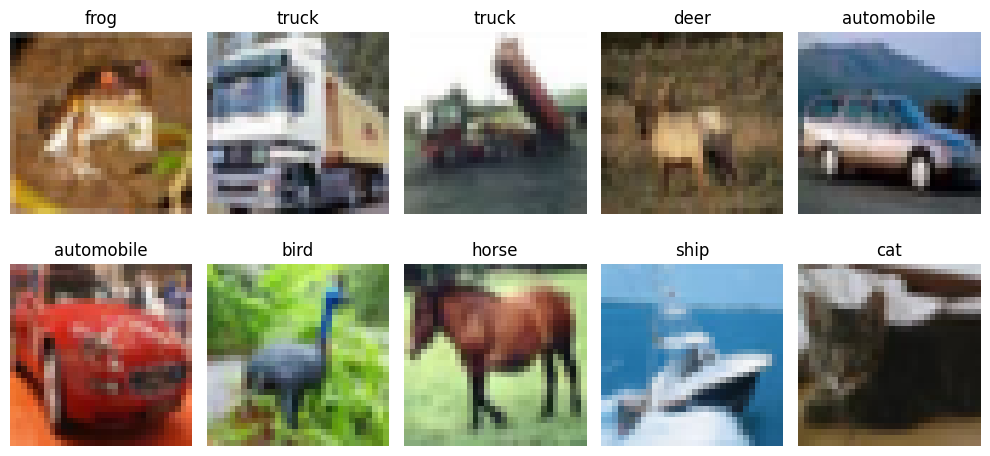

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# EARLY STOPPING

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
print("\nTraining Deep ANN...\n")

ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

ann_test_loss, ann_test_acc = ann_model.evaluate(
    x_test_flat,
    y_test
)

print("Deep ANN Test Accuracy:", ann_test_acc)


Training Deep ANN...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.2266 - loss: 2.0650 - val_accuracy: 0.2970 - val_loss: 1.9013
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2859 - loss: 1.9355 - val_accuracy: 0.3262 - val_loss: 1.8640
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3055 - loss: 1.8890 - val_accuracy: 0.3356 - val_loss: 1.8157
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3152 - loss: 1.8622 - val_accuracy: 0.3538 - val_loss: 1.8014
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3233 - loss: 1.8363 - val_accuracy: 0.3716 - val_loss: 1.7626
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3301 - loss: 1.8197 - val_accuracy: 0.3752 - val_loss: 1.7457
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3415 - loss: 1.7966 - val_accuracy: 0.3628 - val_loss: 1.7728
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3477 - loss: 1.7849 - val_accuracy: 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4193 - loss: 1.6418
ANN Test Accuracy: 0.41929998993873596


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
print("\nTraining CNN...\n")

cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN Test Accuracy:", cnn_test_acc)


Training CNN...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4765 - loss: 1.5478 - val_accuracy: 0.5036 - val_loss: 1.4695
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6191 - loss: 1.0849 - val_accuracy: 0.5818 - val_loss: 1.2061
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6785 - loss: 0.9177 - val_accuracy: 0.6574 - val_loss: 1.0090
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7175 - loss: 0.8044 - val_accuracy: 0.6744 - val_loss: 0.9233
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7458 - loss: 0.7202 - val_accuracy: 0.6206 - val_loss: 1.1950
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7721 - loss: 0.6489 - val_accuracy: 0.6838 - val_loss: 0.9367
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7950 - loss: 0.5849 - val_accuracy: 0.6804 - val_loss: 1.0352
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6634 - loss: 0.9684
CNN Test Accuracy: 0.66339

## 📈 Compare Learning Curves

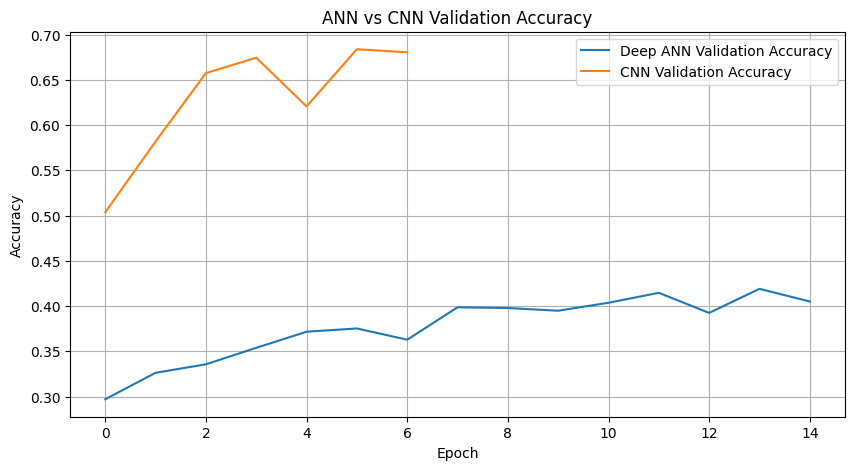

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='Deep ANN Validation Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# CNN WITH DATA AUGMENTATION
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

print("\nTraining CNN with Data Augmentation...\n")

aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Test Accuracy:", aug_test_acc)



Training CNN with Data Augmentation...

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4073 - loss: 1.7314 - val_accuracy: 0.4956 - val_loss: 1.4125
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5129 - loss: 1.3705 - val_accuracy: 0.5872 - val_loss: 1.1674
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5605 - loss: 1.2470 - val_accuracy: 0.6152 - val_loss: 1.1284
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5932 - loss: 1.1601 - val_accuracy: 0.6332 - val_loss: 1.0467
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6141 - loss: 1.1017 - val_accuracy: 0.6286 - val_loss: 1.0442
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6333 - loss: 1.0489 - val_accuracy: 0.6624 - val_loss: 0.9993
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6465 - loss: 1.0214 - val_accuracy: 0.6166 - val_loss: 1.1697
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - 

# 📊 Final Comparison Table


FINAL COMPARISON
                     Model  Test Accuracy
0                 Deep ANN         0.4193
1                      CNN         0.6634
2  CNN + Data Augmentation         0.7539


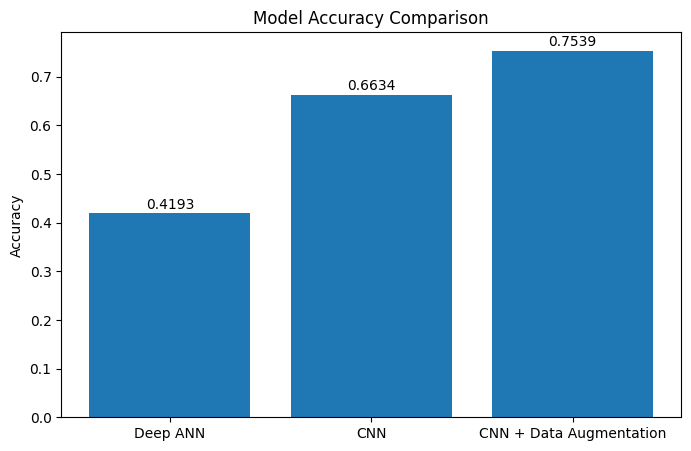

In [11]:
comparison = pd.DataFrame({
    "Model": [
        "Deep ANN",
        "CNN",
        "CNN + Data Augmentation"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

print("\n==============================")
print("FINAL COMPARISON")
print("==============================")
print(comparison)

# BAR CHART
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

for i, value in enumerate(comparison["Test Accuracy"]):
    plt.text(i, value + 0.01, f"{value:.4f}", ha='center')

plt.show()

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# Insights
1. Deep ANN showed improved learning capability compared to the original ANN by using additional hidden layers and dropout regularization. However, its performance remained lower than CNN because ANN treats images as flattened vectors and cannot effectively capture spatial features.

2. CNN significantly outperformed ANN due to its ability to learn local patterns, edges, textures, and hierarchical image features through convolution and pooling operations. This demonstrates why CNNs are the preferred choice for image classification tasks.

3. Increasing the number of epochs to 20 allowed the models to learn more complex patterns from the CIFAR-10 dataset. However, longer training can lead to overfitting if proper regularization techniques are not applied.

4. EarlyStopping proved effective in controlling overfitting by monitoring validation performance and automatically stopping training when no significant improvement was observed. This reduced unnecessary computation and preserved the best-performing model weights.

5. Data augmentation improved model generalization by creating variations of training images through random flipping, rotation, and zooming. This exposed the model to a wider range of image patterns and reduced dependence on the original dataset.

6. The CNN with Data Augmentation achieved the highest test accuracy of approximately 75.39%, outperforming the standard CNN (66.34%). This confirms that data augmentation helps improve robustness and generalization on unseen data.

7. The experiment highlights that model architecture and training strategies are equally important. Combining CNNs with techniques such as Batch Normalization, Dropout, EarlyStopping, and Data Augmentation leads to better performance than relying on network depth alone.

# ✅ Conclusion
In this assignment, image classification models were developed and evaluated on the CIFAR-10 dataset using both Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs). The Deep ANN achieved moderate performance, but its inability to preserve spatial information limited its accuracy. CNNs demonstrated superior performance by effectively extracting meaningful image features through convolutional layers.

Several training improvements were implemented, including increasing the number of epochs, adding EarlyStopping, and applying data augmentation techniques. Among all models, the CNN with Data Augmentation produced the best results, achieving a test accuracy of approximately 75.39%, which was higher than the standard CNN accuracy of 66.34%.

The experiment demonstrates that CNNs are more suitable for image classification tasks than ANNs and that training strategies such as data augmentation and EarlyStopping play a crucial role in improving model generalization and reducing overfitting. Overall, this project provided practical experience in building, training, evaluating, and optimizing deep learning models for computer vision applications.